### Jupyter notebook for practice quiz for lesson 2.3.3
This Jupyter notebook executes the "processDynamic.m" code to generate a dynamic cell model from cell-test data. The results computed by this notebook will be used to answer questions in the practice quiz for lesson 2.3.3.

In [11]:
% Set the toolkit to gnuplot
graphics_toolkit('gnuplot');

% langsung jalankan processDyanmic
clear all
temps = 25;

numpoles = 1; % number of resistor--capacitor pairs in final model
doHyst = 1;   % whether to include hysteresis in model

% Read model OCV file
modelFile = sprintf('staticModel-ocv.mat');
load(modelFile);

% used by fminbnd later on
options=optimset('TolX',1e-8,'TolFun',1e-8,'MaxFunEval',100000, ...
 'MaxIter',1e6,'Jacobian','Off', 'Display', 'iter'); % for later optimization
options=optimset('TolX',0.1,'TolFun',1e-2,'MaxFunEval',40, ...
 'MaxIter',20,'Jacobian','Off', 'Display', 'iter'); % for later optimization

% load "cell_18ah_dynStep1.csv" and dynStep2.csv
% and plot it
% 1. Load the data (skipping the first 6 lines of headers in your CSV)
raw_data1 = dlmread('cell_18ah_dynStep1.csv', ',', 7, 0);
raw_data2 = dlmread('cell_18ah_dynStep2.csv', ',', 15, 0);

% Force raw_data2 to only have the first 3 columns
raw_data2 = raw_data2(:, 1:3);
% Calculate the last timestamp of the first file
last_time = raw_data1(end, 1);

% Add that offset to the time column (column 1) of the second file
raw_data2(:, 1) = raw_data2(:, 1) + last_time;

% Now combine them
raw_data = [raw_data1; raw_data2];

% 2. Initialize an empty structure (This prevents the "empty structure array" error)
data = struct();

% 3. Assign the columns to the structure fields
% Column 1: Time(S), Column 2: Cur(A), Column 3: Vol(V)
data.script1.time = raw_data(:, 1);
data.script1.current = raw_data(:, 2);
data.script1.voltage = raw_data(:, 3);

%freeing data from memory
clear raw_data raw_data1 raw_data2;

In [12]:
% Now, script2 - vmin and dither_vmin
% load "cell_18ah_dynStep3_vmin.csv" and dynStep3_dither_vmin.csv
% and plot it
% 1. Load the data (skipping the first 6 lines of headers in your CSV)
raw_data1 = dlmread('cell_18ah_dynStep3_vmin.csv', ',', 8, 0);
raw_data2 = dlmread('cell_18ah_dynStep3_dither_vmin.csv', ',', 27, 0);

% Force raw_data2 to only have the first 3 columns
raw_data2 = raw_data2(:, 1:3);
% Calculate the last timestamp of the first file
last_time = raw_data1(end, 1);

% Add that offset to the time column (column 1) of the second file
raw_data2(:, 1) = raw_data2(:, 1) + last_time;

% Now combine them
raw_data = [raw_data1; raw_data2];

% 3. Assign the columns to the structure fields
% Column 1: Time(S), Column 2: Cur(A), Column 3: Vol(V)
data.script2.time = raw_data(:, 1);
data.script2.current = raw_data(:, 2);
data.script2.voltage = raw_data(:, 3);

%freeing data from memory
clear raw_data raw_data1 raw_data2;

% 4. Save to the MAT file
% save('cell_18ah_dynStep1.mat', 'data');

In [3]:
% Now, script3 - vmax and dither_vmax
% load "cell_18ah_dynStep4_vmax.csv" and dynStep4_dither_vmax.csv
% and plot it
% 1. Load the data (skipping the first 6 lines of headers in your CSV)
raw_data1 = dlmread('cell_18ah_dynStep4_vmax.csv', ',', 8, 0);
raw_data2 = dlmread('cell_18ah_dynStep4_dither_vmax.csv', ',', 27, 0);

% Force raw_data2 to only have the first 3 columns
raw_data2 = raw_data2(:, 1:3);
% Calculate the last timestamp of the first file
last_time = raw_data1(end, 1);

% Add that offset to the time column (column 1) of the second file
raw_data2(:, 1) = raw_data2(:, 1) + last_time;

% Now combine them
raw_data = [raw_data1; raw_data2];

% 3. Assign the columns to the structure fields
% Column 1: Time(S), Column 2: Cur(A), Column 3: Vol(V)
data.script3.time = raw_data(:, 1);
data.script3.current = raw_data(:, 2);
data.script3.voltage = raw_data(:, 3);

%freeing data from memory
clear raw_data raw_data1 raw_data2;

% 4. Save to the MAT file
save('cell_18ah_dynStep.mat', 'data');

### Visualizing data
There is an enormous amount of data stored from these four cell tests. One good way to visualize the data is via plotting. For example:

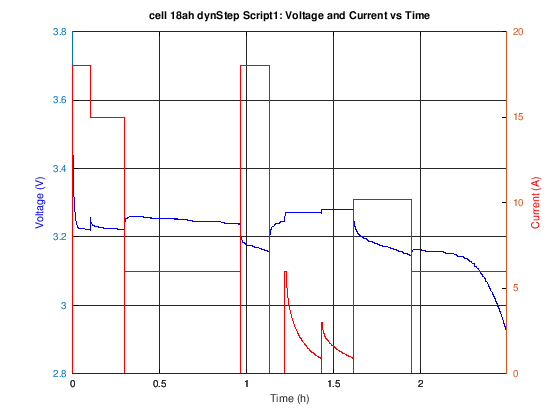

In [13]:
load cell_18ah_dynStep.mat;
[ax1, h1, h2] = plotyy(data.script1.time/3600, data.script1.voltage, data.script1.time/3600, data.script1.current);

% 5. Customize the line styles (Optional but makes it look better)
set(h1, 'linewidth', 2, 'color', 'b'); % Voltage line (Blue)
set(h2, 'linewidth', 2, 'color', 'r'); % Current line (Red)

% 6. Add labels and title
xlabel('Time (h)', 'fontsize', 12);
ylabel(ax1(1), 'Voltage (V)', 'fontsize', 12, 'color', 'b');
ylabel(ax1(2), 'Current (A)', 'fontsize', 12, 'color', 'r');
title('cell 18ah dynStep Script1: Voltage and Current vs Time', 'fontsize', 14);

grid on;

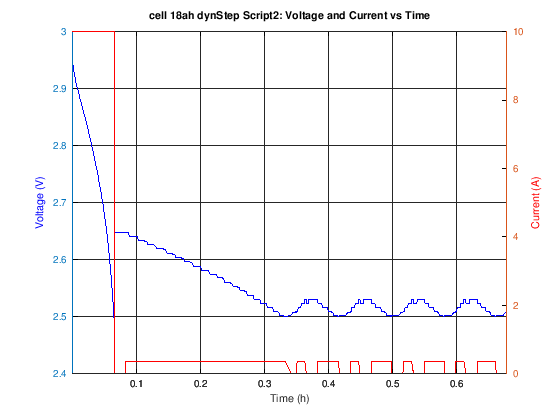

In [14]:
[ax2, h1, h2] = plotyy(data.script2.time/3600, data.script2.voltage, data.script2.time/3600, data.script2.current);

% 5. Customize the line styles (Optional but makes it look better)
set(h1, 'linewidth', 2, 'color', 'b'); % Voltage line (Blue)
set(h2, 'linewidth', 2, 'color', 'r'); % Current line (Red)

% 6. Add labels and title
xlabel('Time (h)', 'fontsize', 12);
ylabel(ax2(1), 'Voltage (V)', 'fontsize', 12, 'color', 'b');
ylabel(ax2(2), 'Current (A)', 'fontsize', 12, 'color', 'r');
title('cell 18ah dynStep Script2: Voltage and Current vs Time', 'fontsize', 14);
% 7. Add grid and legend

grid on;

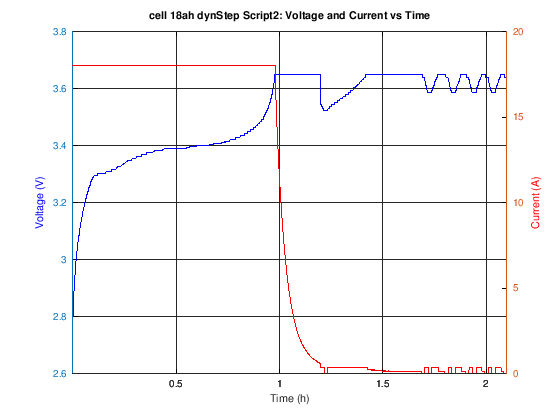

In [15]:
[ax3, h1, h2] = plotyy(data.script3.time/3600, data.script3.voltage, data.script3.time/3600, data.script3.current);

% 5. Customize the line styles (Optional but makes it look better)
set(h1, 'linewidth', 2, 'color', 'b'); % Voltage line (Blue)
set(h2, 'linewidth', 2, 'color', 'r'); % Current line (Red)

% 6. Add labels and title
xlabel('Time (h)', 'fontsize', 12);
ylabel(ax3(1), 'Voltage (V)', 'fontsize', 12, 'color', 'b');
ylabel(ax3(2), 'Current (A)', 'fontsize', 12, 'color', 'r');
title('cell 18ah dynStep Script2: Voltage and Current vs Time', 'fontsize', 14);
% 7. Add grid and legend

grid on;

In [16]:
% ------------------------------------------------------------------
% Step 1: Compute capacity and coulombic efficiency for every test
% ------------------------------------------------------------------

% get disAh from each csv file and directly put into disAh variable
% get chgAh from each csv file and directly put into chgAh variable

% 1. Open the file for reading
fid = fopen('cell_18ah_dynStep1.csv', 'r');

% Variables to store our extracted capacities
totDisAh = 0;
totChgAh = 0;

% 2. Loop through the file line by line
while ~feof(fid)
    % Read the current line
    line = fgetl(fid);
    
    % Check if we reached the main data (so we can stop reading)
    if strncmp(line, 'Time(S)', 7)
        break; 
    end
    
    % 3. Look for step 1-3
    if strncmp(line, '*1-1', 4)
        % Split the line into parts using the comma as a delimiter
        % Example line: *1-3,C-CV,20.87,69.97
        parts = strsplit(line, ',');
        
        % The capacity is the 3rd item. Convert it from text to a number
        totDisAh = totDisAh + str2double(parts{3});
    end
end

% 5. Close the file (important to free up system resources!)
fclose(fid);
% first initialize disAh
% 15.833 data from dynStep2.csv
data.script1.disAh = totDisAh + 16.663;
data.script1.chgAh = 0.78;

% script2.disAh dari Step3_vmin dan Step3_dither_vmin
data.script2.disAh = 0.646 + 0.134;
data.script2.chgAh = 0.02;

% script3.disAh dari step4_dither_vmax
data.script3.disAh = 0.03;
data.script3.chgAh = 0.161 + 18.57;
% sum all totDisAh
totDisAh = data.script1.disAh + data.script2.disAh + data.script3.disAh;
totChgAh = data.script1.chgAh + data.script2.chgAh + data.script3.chgAh;
eta25 = totDisAh/totChgAh;

data.script1.chgAh = data.script1.chgAh*eta25;
data.script2.chgAh = data.script2.chgAh*eta25;
data.script3.chgAh = data.script3.chgAh*eta25;    

Q25 = data.script1.disAh(end) + data.script2.disAh(end) -...
      data.script1.chgAh(end) - data.script2.chgAh(end);
data.Q = Q25;
% Display the results
fprintf('Capacity for Charge Ah: %.3f Ah\n', totChgAh);
fprintf('Capacity for Discharge Ah: %.3f Ah\n', data.script1.disAh);
fprintf('eta25: %.3f\n', eta25);
fprintf('Q25: %.3f\n', Q25);

model.temp = 25;
model.etaParam = NaN;
model.QParam = NaN;
































































Capacity for Charge Ah: 19.531 Ah

Capacity for Discharge Ah: 18.460 Ah

eta25: 0.987

Q25: 18.451






In [17]:
% ------------------------------------------------------------------
% Step 2: Compute OCV for "discharge portion" of test
% ------------------------------------------------------------------
% for k = 1:length(data),
    etaParam = model.etaParam;
    etaik = data.script1.current(:); % Forced to column vector
    etaik(etaik<0)= etaParam*etaik(etaik<0);
    % disp(etaik)
    % disp(data.Q)
    data.Z = 1 - cumsum([0; etaik(1:end-1)]) * 1/(data.Q*3600); 
    data.OCV = OCVfromSOCtemp(data.Z(:),25,model);
% end

In [18]:
% ------------------------------------------------------------------
  % Step 3: Now, optimize!
  % ------------------------------------------------------------------
  model.GParam  = NaN; 
  model.M0Param = NaN; 
  model.MParam  = NaN; 
  model.R0Param = NaN; 
  model.RCParam = NaN(1,numpoles); 
  model.RParam  = NaN(1,numpoles); 

  fprintf('Processing temperature 25°C\n');
  bestcost = Inf;
  % used by fminbnd later on
options=optimset('TolX',1e-8,'TolFun',1e-8,'MaxFunEval',100000, ...
 'MaxIter',1e6,'Jacobian','Off', 'Display', 'iter'); % for later optimization
options=optimset('TolX',0.1,'TolFun',1e-2,'MaxFunEval',40, ...
 'MaxIter',20,'Jacobian','Off', 'Display', 'iter'); % for later optimization












Processing temperature 25°C








In [19]:
% disp(fieldnames(model))
disp(model.temp)

% Find which column corresponds to the requested temperature
paramName = 'RParam';
temperature = 25;

    tempIndex = find(model.temp == temperature);
    
    if isempty(tempIndex)
        error('Temperature %d not found in the model.', temperature);
    end
    
    % If it is an RC parameter, it might be a matrix, so return the row
    if strcmp(paramName, 'RCParam') || strcmp(paramName, 'RParam')
        value = model.(paramName)(tempIndex, :);
    else
        % Otherwise, return the single value
        value = model.(paramName)(tempIndex);
    end
disp(value)



25



















NaN


In [25]:
% Call the function file from your hard drive
model = processDynamic(data, model, 1, 1); % Set numpoles to 1, doHyst to 0
modelFile = sprintf('cell18model.mat');
save(modelFile,'model');



Processing temperature 25°C
    Trying np = 1...
  RMS error for present value of gamma = 46.36 (mV)
    The model created for this value of gamma is the best ESC model yet!
    Trying np = 1...
  RMS error for present value of gamma = 46.43 (mV)
    Trying np = 1...
  RMS error for present value of gamma = 46.23 (mV)
    The model created for this value of gamma is the best ESC model yet!
    Trying np = 1...
  RMS error for present value of gamma = 45.79 (mV)
    The model created for this value of gamma is the best ESC model yet!
    Trying np = 1...
  RMS error for present value of gamma = 44.71 (mV)
    The model created for this value of gamma is the best ESC model yet!
    Trying np = 1...
  RMS error for present value of gamma = 42.35 (mV)
    The model created for this value of gamma is the best ESC model yet!
    Trying np = 1...
  RMS error for present value of gamma = 38.86 (mV)
    The model created for this value of gamma is the best ESC model yet!
    Trying np = 1...


In [26]:
% disp(modelFile)

% fieldnames(model)

disp(model)








    OCV0 =

     Columns 1 through 8:

       2.6190   2.7699   2.8486   2.9046   2.9521   2.9906   3.0202   3.0487

     Columns 9 through 16:

       3.0732   3.0955   3.1133   3.1338   3.1483   3.1629   3.1764   3.1909

     Columns 17 through 24:

       3.2042   3.2120   3.2245   3.2321   3.2316   3.2381   3.2386   3.2382

     Columns 25 through 32:

       3.2377   3.2372   3.2368   3.2363   3.2391   3.2413   3.2409   3.2407

     Columns 33 through 40:

       3.2409   3.2405   3.2400   3.2405   3.2450   3.2456   3.2451   3.2516

     Columns 41 through 48:

       3.2522   3.2517   3.2562   3.2577   3.2573   3.2621   3.2633   3.2629

     Columns 49 through 56:

       3.2654   3.2697   3.2695   3.2690   3.2745   3.2750   3.2746   3.2771

     Columns 57 through 64:

       3.2796   3.2802   3.2797   3.2792   3.2847   3.2845   3.2848   3.2843

     Columns 65 through 72:

       3.2849   3.2904   3.2909   3.2904   3.2900   3.2945   3.2950   3.2956

     Columns 73 through

### Using the model
Once the model has been created, you can load it from the file in which it was saved, and can look at its basic structures.

In [27]:
% Load model data file
load cell18model.mat
temp = model.temp % display the temperatures processed to create the model
capacities = model.QParam % display measured total capacities at each temperature




temp = 25

capacities = 18.451


In [ ]:
% Plot model fields: resistances
subplot(1,2,1); plot(model.temps,1000*model.R0Param)
xlabel('Temperature (degC)'); ylabel('Resistance (mOhms)'); title('Series resistance versus temperature')
subplot(1,2,2); plot(model.temps,1000*model.RParam)
xlabel('Temperature (degC)'); ylabel('Resistance (mOhms)'); title('R-C resistance versus temperature')

In [ ]:
model.GParam()


In [ ]:
model.MParam()
